# Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive"
print(os.listdir(base_path))

['Competitive Research.gsheet', 'Untitled document (14).gdoc', 'Untitled spreadsheet (7).gsheet', 'Untitled project.gscript', 'Untitled spreadsheet (6).gsheet', 'Info.gdoc', 'แผนงาน : PM.gdoc', 'HelpDesk Categorized.gsheet', 'Untitled document (13).gdoc', 'Untitled spreadsheet (5).gsheet', 'Trend Summary.gdoc', 'Untitled document (12).gdoc', 'ตารางลงเวลา.gsheet', 'DC.gdoc', 'Untitled document (11).gdoc', 'Untitled document (10).gdoc', 'จดภาษี.gsheet', 'Untitled document (9).gdoc', 'โจทย์ C#.gdoc', 'Untitled document (8).gdoc', 'Practice 2.gdoc', 'Untitled spreadsheet (4).gsheet', 'สมุดบันทึกการฝึกสหกิจศึกษา (1).gdoc', 'Untitled document (7).gdoc', 'examination1-65-1.gdoc', 'Assignment: Docker.gdoc', 'Untitled document (6).gdoc', 'LSTM_Explaination.gdoc', 'Untitled document (5).gdoc', 'Untitled document (4).gdoc', 'Assignment FastAPI_1650901679.gdoc', 'Untitled document (3).gdoc', 'Colab Notebooks', 'Workshop_1650901679.gdoc', 'ตัวอย่างการยิง API ไปยัง AI.gdoc', 'Assignment_Async_165090

In [ ]:
data_path = "/content/drive/MyDrive/AI494/Data"
print(os.listdir(data_path))

['Usagi', 'Hachiware', 'Chiikawa', 'multi_character', 'multi-character-2']


In [ ]:
import os
import random
import shutil

src_dir = "/content/drive/MyDrive/AI494/Data"
dst_dir = "/content/drive/MyDrive/AI494/dataset_split"

train_dir = os.path.join(dst_dir, "train")
val_dir = os.path.join(dst_dir, "val")

random.seed(42)

SKIP_CLASSES = ["multi_character", "multi-character-2"]

# ===== เก็บข้อมูล =====
class_images = {}
class_counts = {}

for class_name in os.listdir(src_dir):
    if class_name.lower() in SKIP_CLASSES:
        continue

    class_path = os.path.join(src_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    if len(images) > 0:
        class_images[class_name] = images
        class_counts[class_name] = len(images)

# ===== report ก่อน split =====
print("📊 BEFORE SPLIT")
for c, n in class_counts.items():
    print(f"{c}: {n} images")

# ===== หา min =====
min_count = min(class_counts.values())
print(f"\n🔢 ใช้ {min_count} รูปต่อ class (balanced)")

split_ratio = 0.2

# ===== split =====
report = {}

for class_name, images in class_images.items():
    class_path = os.path.join(src_dir, class_name)

    random.shuffle(images)

    images = images[:min_count]

    split_point = int(len(images) * split_ratio)

    val_images = images[:split_point]
    train_images = images[split_point:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_dir, class_name, img)
        )

    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(val_dir, class_name, img)
        )

    report[class_name] = {
        "train": len(train_images),
        "val": len(val_images)
    }

# ===== report หลัง split =====
print("\n📊 AFTER SPLIT")
total_train = 0
total_val = 0

for c, stats in report.items():
    print(f"{c}: train={stats['train']} | val={stats['val']}")
    total_train += stats['train']
    total_val += stats['val']

print("\n📦 TOTAL")
print(f"Train Total: {total_train}")
print(f"Val Total: {total_val}")
print(f"Grand Total: {total_train + total_val}")

📊 BEFORE SPLIT
Usagi: 30 images
Hachiware: 30 images
Chiikawa: 24 images

🔢 ใช้ 24 รูปต่อ class (balanced)

📊 AFTER SPLIT
Usagi: train=20 | val=4
Hachiware: train=20 | val=4
Chiikawa: train=20 | val=4

📦 TOTAL
Train Total: 60
Val Total: 12
Grand Total: 72


# Training


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/content/drive/MyDrive/AI494/dataset_split/train"
val_dir = "/content/drive/MyDrive/AI494/dataset_split/val"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(pretrained=True)

num_classes = len(train_dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== MODEL =====
model = models.mobilenet_v3_small(pretrained=True)
num_classes = len(train_dataset.classes)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model = model.to(device)

# ===== LOSS =====
train_criterion = nn.CrossEntropyLoss(reduction='none')
val_criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0003)

# 🔥 scheduler (สำคัญมากเวลา epoch เยอะ)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

# ===== SAVE DIR =====
save_dir = "/content/drive/MyDrive/AI494/models/mobilenetv3"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "mobilenetv3_best.pth")

# ===== TRAIN CONFIG =====
EPOCHS = 300
PATIENCE = 5   # เพิ่มนิดนึงให้เหมาะกับ epoch เยอะ

best_val_loss = float("inf")
patience_counter = 0

WRONG_WEIGHT = 2.0
CORRECT_WEIGHT = 1.0

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        losses = train_criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        weights = torch.where(
            preds == labels,
            torch.tensor(CORRECT_WEIGHT, device=device),
            torch.tensor(WRONG_WEIGHT, device=device)
        )

        loss = (losses * weights).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ================= VALID =================
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = val_criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    # 🔥 update LR
    scheduler.step(val_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ================= SAVE BEST =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "model_state": model.state_dict(),
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "classes": train_dataset.classes
        }, best_model_path)

        print(f"✅ Updated BEST model (epoch {epoch+1})")

    else:
        patience_counter += 1
        print(f"⏳ ไม่ดีขึ้น ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

print(f"\n🏁 Training finished. Best val loss: {best_val_loss:.4f}")
print(f"📦 Saved at: {best_model_path}")


Epoch 1
Train Loss: 1.7628 | Val Loss: 1.0278
LR: 0.000300
✅ Updated BEST model (epoch 1)

Epoch 2
Train Loss: 0.7124 | Val Loss: 0.9636
LR: 0.000300
✅ Updated BEST model (epoch 2)

Epoch 3
Train Loss: 0.4401 | Val Loss: 0.9046
LR: 0.000300
✅ Updated BEST model (epoch 3)

Epoch 4
Train Loss: 0.2790 | Val Loss: 0.8393
LR: 0.000300
✅ Updated BEST model (epoch 4)

Epoch 5
Train Loss: 0.2175 | Val Loss: 0.7756
LR: 0.000300
✅ Updated BEST model (epoch 5)

Epoch 6
Train Loss: 0.1009 | Val Loss: 0.7052
LR: 0.000300
✅ Updated BEST model (epoch 6)

Epoch 7
Train Loss: 0.0491 | Val Loss: 0.6436
LR: 0.000300
✅ Updated BEST model (epoch 7)

Epoch 8
Train Loss: 0.0287 | Val Loss: 0.5900
LR: 0.000300
✅ Updated BEST model (epoch 8)

Epoch 9
Train Loss: 0.0163 | Val Loss: 0.5438
LR: 0.000300
✅ Updated BEST model (epoch 9)

Epoch 10
Train Loss: 0.0144 | Val Loss: 0.5059
LR: 0.000300
✅ Updated BEST model (epoch 10)

Epoch 11
Train Loss: 0.0059 | Val Loss: 0.4756
LR: 0.000300
✅ Updated BEST model (epoch

## Evaluate

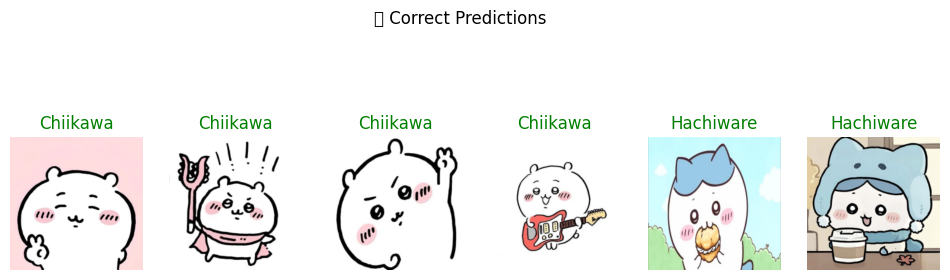


===== Overall =====
Total: 12
Correct: 12
Accuracy: 1.0000

===== Per Class =====
Chiikawa: 4/4 = 1.0000
Hachiware: 4/4 = 1.0000
Usagi: 4/4 = 1.0000


In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

model.eval()

class_names = val_dataset.classes

def imshow(img):
    img = img.permute(1, 2, 0)
    plt.imshow(img.cpu())
    plt.axis('off')

# ===== stats =====
total = 0
correct = 0

class_correct = defaultdict(int)
class_total = defaultdict(int)

# ===== เก็บตัวอย่าง =====
correct_samples = []
wrong_samples = []

MAX_SHOW = 6  # จำนวนรูปที่จะแสดงต่อกลุ่ม

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            pred = preds[i].item()

            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1
                if len(correct_samples) < MAX_SHOW:
                    correct_samples.append((images[i].cpu(), label, pred))
            else:
                if len(wrong_samples) < MAX_SHOW:
                    wrong_samples.append((images[i].cpu(), label, pred))

# ===== แสดง Correct =====
if len(correct_samples) > 0:
    plt.figure(figsize=(12, 4))
    plt.suptitle("✅ Correct Predictions")

    for i, (img, label, pred) in enumerate(correct_samples):
        plt.subplot(1, MAX_SHOW, i+1)
        imshow(img)

        true_label = class_names[label]
        pred_label = class_names[pred]

        plt.title(f"{true_label}", color="green")

    plt.show()

# ===== แสดง Wrong =====
if len(wrong_samples) > 0:
    plt.figure(figsize=(12, 4))
    plt.suptitle("❌ Wrong Predictions")

    for i, (img, label, pred) in enumerate(wrong_samples):
        plt.subplot(1, MAX_SHOW, i+1)
        imshow(img)

        true_label = class_names[label]
        pred_label = class_names[pred]

        plt.title(f"T:{true_label}\nP:{pred_label}", color="red")

    plt.show()

# ===== สรุปผลรวม =====
print("\n===== Overall =====")
print(f"Total: {total}")
print(f"Correct: {correct}")
print(f"Accuracy: {correct/total:.4f}")

# ===== สรุปราย class =====
print("\n===== Per Class =====")
for i, class_name in enumerate(class_names):
    if class_total[i] > 0:
        acc = class_correct[i] / class_total[i]
        print(f"{class_name}: {class_correct[i]}/{class_total[i]} = {acc:.4f}")
    else:
        print(f"{class_name}: ไม่มีข้อมูลใน val")

In [ ]:
import os
from datetime import datetime

save_dir = "/content/drive/MyDrive/AI494/models"
os.makedirs(save_dir, exist_ok=True)

# 👉 สร้างชื่ออัตโนมัติ
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"mobilenetv3_epoch{epoch+1}_val{val_loss:.3f}_{timestamp}.pth"
path = os.path.join(save_dir, filename)

torch.save({
    "model_state": model.state_dict(),
    "model_name": "mobilenetv3",
    "epoch": epoch,
    "val_loss": val_loss,
    "classes": train_dataset.classes
}, path)

print(f"💾 Saved to: {path}")

💾 Saved to: /content/drive/MyDrive/AI494/models/mobilenetv3_epoch159_val0.029_20260430_084006.pth


In [ ]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models_dir = "/content/drive/MyDrive/AI494/models"

results = []

for root, dirs, files in os.walk(models_dir):
    for file in files:
        if file.endswith(".pth"):
            path = os.path.join(root, file)

            print(f"\n🚀 Evaluating: {file}")

            # ===== 📦 size =====
            size_mb = os.path.getsize(path) / (1024 * 1024)

            # ===== โหลด checkpoint =====
            checkpoint = torch.load(path, map_location=device)

            # ⚠️ สร้าง model ให้ตรง
            model = models.mobilenet_v3_small(pretrained=False)
            num_classes = len(checkpoint["classes"])
            model.classifier[3] = torch.nn.Linear(
                model.classifier[3].in_features,
                num_classes
            )

            model.load_state_dict(checkpoint["model_state"])
            model.to(device)
            model.eval()

            # ===== accuracy =====
            correct = 0
            total = 0

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)

                    outputs = model(images)
                    _, preds = torch.max(outputs, 1)

                    total += labels.size(0)
                    correct += (preds == labels).sum().item()

            acc = correct / total

            # ===== latency =====
            dummy = torch.randn(1, 3, 224, 224).to(device)

            for _ in range(10):  # warmup
                _ = model(dummy)

            import time
            start = time.time()

            with torch.no_grad():
                for _ in range(50):
                    _ = model(dummy)

            end = time.time()
            latency = (end - start) / 50

            # ===== save result =====
            results.append({
                "model": file,
                "accuracy": acc,
                "latency_ms": latency * 1000,
                "size_mb": size_mb
            })

# ===== summary =====
print("\n📊 RESULT")
for r in results:
    print(
        f"{r['model']} | "
        f"Acc: {r['accuracy']:.4f} | "
        f"Latency: {r['latency_ms']:.2f} ms | "
        f"Size: {r['size_mb']:.2f} MB"
    )


🚀 Evaluating: mobilenetv3_epoch100_val0.260_20260430_083452.pth

🚀 Evaluating: mobilenetv3_epoch65_val0.228_20260430_083647.pth

🚀 Evaluating: mobilenetv3_epoch159_val0.029_20260430_084006.pth

🚀 Evaluating: mobilenetv3_best.pth

📊 RESULT
mobilenetv3_epoch100_val0.260_20260430_083452.pth | Acc: 0.9167 | Latency: 5.12 ms | Size: 5.94 MB
mobilenetv3_epoch65_val0.228_20260430_083647.pth | Acc: 0.9167 | Latency: 5.03 ms | Size: 5.94 MB
mobilenetv3_epoch159_val0.029_20260430_084006.pth | Acc: 1.0000 | Latency: 4.90 ms | Size: 5.94 MB
mobilenetv3_best.pth | Acc: 1.0000 | Latency: 5.25 ms | Size: 5.93 MB


## Conversion

In [ ]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== path =====
checkpoint_path = "/content/drive/MyDrive/AI494/models/mobilenetv3/mobilenetv3_best.pth"

# ===== model =====
model = models.mobilenet_v3_small(pretrained=False)

num_classes = 3  # หรือ len(checkpoint["classes"])
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

# ===== load =====
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])

model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [ ]:
!pip install onnxruntime onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 48.6 MB/s eta 0:00:00


In [ ]:
!pip install onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.9 MB/s eta 0:00:00


In [ ]:
onnx_path = "/content/drive/MyDrive/AI494/models/mobilenetv3/mobilenetv3.onnx"

# 🔥 แนะนำให้ใช้ CPU ตอน export (เสถียรกว่า)
model = model.to("cpu")
model.eval()

dummy = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=11,     # 🔥 downgrade
    dynamo=False          # 🔥 ตัวแก้หลัก
)

print("✅ Export ONNX success (fixed)")

/tmp/ipykernel_1743/4108230283.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ Export ONNX success (fixed)


In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quant_path = "/content/drive/MyDrive/AI494/models/mobilenetv3/mobilenetv3_quant.onnx"

quantize_dynamic(
    model_input=onnx_path,
    model_output=quant_path,
    weight_type=QuantType.QUInt8
)

print(f"✅ Quantized model saved at: {quant_path}")

✅ Quantized model saved at: /content/drive/MyDrive/AI494/models/mobilenetv3/mobilenetv3_quant.onnx


In [ ]:
import torch
import onnxruntime as ort
import numpy as np
import time
import os

# ======================
# PYTORCH LATENCY
# ======================
model.to(device)
model.eval()

dummy_torch = torch.randn(1, 3, 224, 224).to(device)

for _ in range(10):
    _ = model(dummy_torch)

start = time.time()
with torch.no_grad():
    for _ in range(100):
        _ = model(dummy_torch)
end = time.time()

torch_latency = (end - start) / 100

# ======================
# ONNX LATENCY
# ======================
dummy_np = np.random.randn(1, 3, 224, 224).astype(np.float32)

session = ort.InferenceSession(onnx_path)

for _ in range(10):
    session.run(None, {"input": dummy_np})

start = time.time()
for _ in range(100):
    session.run(None, {"input": dummy_np})
end = time.time()

onnx_latency = (end - start) / 100

# ======================
# QUANT LATENCY
# ======================
session_q = ort.InferenceSession(quant_path)

for _ in range(10):
    session_q.run(None, {"input": dummy_np})

start = time.time()
for _ in range(100):
    session_q.run(None, {"input": dummy_np})
end = time.time()

quant_latency = (end - start) / 100

# ======================
# MODEL SIZE
# ======================
pth_size = os.path.getsize(checkpoint_path) / (1024*1024)
onnx_size = os.path.getsize(onnx_path) / (1024*1024)
quant_size = os.path.getsize(quant_path) / (1024*1024)

# ======================
# TABLE OUTPUT
# ======================
print("\n📊 MODEL COMPARISON TABLE")
print("="*60)
print(f"{'Model':<15}{'Latency (ms)':<20}{'Size (MB)':<15}")
print("-"*60)

print(f"{'PyTorch':<15}{torch_latency*1000:<20.2f}{pth_size:<15.2f}")
print(f"{'ONNX':<15}{onnx_latency*1000:<20.2f}{onnx_size:<15.2f}")
print(f"{'Quantized':<15}{quant_latency*1000:<20.2f}{quant_size:<15.2f}")

print("="*60)


📊 MODEL COMPARISON TABLE
Model          Latency (ms)        Size (MB)      
------------------------------------------------------------
PyTorch        10.88               5.93           
ONNX           2.83                5.82           
Quantized      13.99               1.62           
